# Experiment Validation & Exploratory Data Analysis

## Business Context

Before evaluating the results of an A/B test, it is essential to verify that the experiment was conducted correctly. If users were not randomly assigned to the experimental groups, any statistical conclusions may be unreliable.

This notebook validates the experiment design and explores player behavior to identify patterns, anomalies, and potential issues before hypothesis testing.

---

## Objectives

- Validate experiment randomization using a Sample Ratio Mismatch (SRM) check.
- Explore player engagement and retention patterns.
- Identify outliers and understand the distribution of key variables.
- Generate insights that guide the statistical analysis in the next phase.

## Import Required Libraries

Import the libraries required for experiment validation, statistical testing, and data visualization.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import chisquare

## Load Dataset

Load the cleaned dataset for experiment validation and exploratory analysis.

In [2]:
df = pd.read_csv("../data/raw/cookie_cats.csv")

# 1. Sample Ratio Mismatch (SRM)

## Objective

Verify that players were randomly assigned to the two experiment groups. A significant imbalance may indicate issues with experiment implementation, making subsequent statistical conclusions unreliable.

### What is SRM?

Sample Ratio Mismatch (SRM) occurs when the observed allocation of users differs significantly from the expected allocation. Since Cookie Cats was designed as a 50:50 A/B experiment, both groups should contain approximately the same number of players.

A Chi-Square Goodness-of-Fit Test is used to determine whether any observed difference is due to random variation or indicates a potential problem with the experiment.

### Step 1: Count Players in Each Variant

Count the number of players assigned to each experimental group to obtain the observed allocation.

In [3]:
df["version"].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

# 1. Experiment Group Distribution

## Objective

Examine the distribution of players across the control and treatment groups to verify that both variants contain comparable numbers of participants before further analysis.

In [8]:
df["version"].value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

In [9]:
(df["version"].value_counts(normalize=True)*100).round(2)

version
gate_40    50.44
gate_30    49.56
Name: proportion, dtype: float64

### Key Insights

- The dataset contains **44,700** players in the `gate_30` group and **45,489** players in the `gate_40` group.
- The two experiment groups contain nearly equal numbers of players, with approximately **49.56%** assigned to `gate_30` and **50.44%** assigned to `gate_40`.
- The observed allocation appears balanced and consistent with a randomized A/B experiment.

### Business Relevance

- Similar group sizes reduce the likelihood that differences in retention are driven by unequal sample sizes.
- The experiment appears suitable for comparing player behavior between the two game versions.

# 2. Distribution of Player Engagement

## Objective

Examine the distribution of total game rounds played (`sum_gamerounds`) to understand player engagement patterns and identify potential skewness or extreme observations before statistical analysis.

### 2.1 Standard Histogram

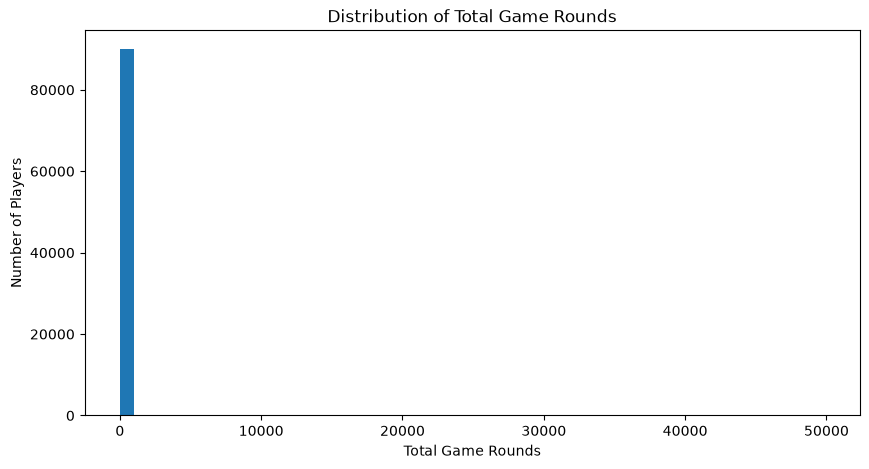

In [10]:
plt.figure(figsize=(10,5))

plt.hist(df["sum_gamerounds"], bins=50)

plt.title("Distribution of Total Game Rounds")
plt.xlabel("Total Game Rounds")
plt.ylabel("Number of Players")

plt.show()

### Key Insights

- The distribution is **highly right-skewed**, with most players completing relatively few game rounds.
- A small number of players have exceptionally high play counts, creating a long right tail.
- The presence of extreme values compresses the majority of observations, making the overall distribution difficult to interpret.
- A standard histogram is insufficient for understanding the engagement pattern because the extreme values dominate the x-axis.

### Business Relevance

- Player engagement is not evenly distributed; most users are casual players while a small fraction are highly engaged.
- Before making decisions about outliers, further investigation is required to determine whether these observations represent genuine player behavior or anomalous records. 

### 2.2 Log-Transformed Histogram

#### Objective

Apply a logarithmic transformation to the engagement variable to reduce the influence of extreme values and reveal the underlying distribution of player activity.

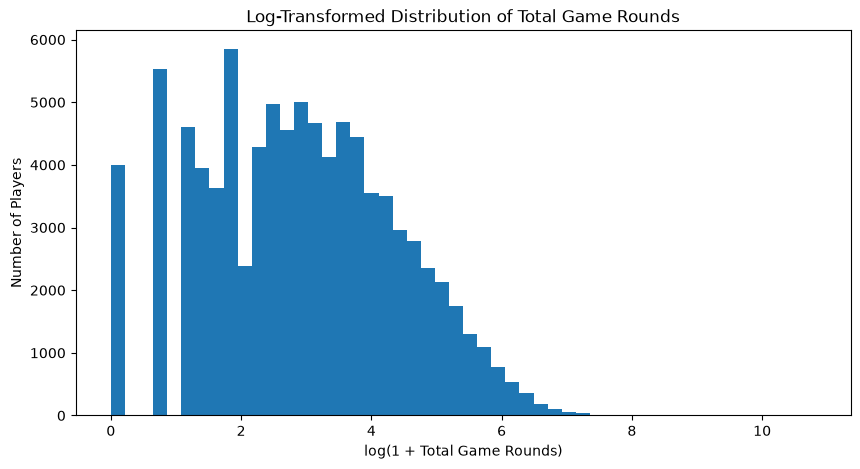

In [13]:
log_rounds = np.log1p(df["sum_gamerounds"])

plt.figure(figsize=(10, 5))

plt.hist(log_rounds, bins=50)

plt.title("Log-Transformed Distribution of Total Game Rounds")
plt.xlabel("log(1 + Total Game Rounds)")
plt.ylabel("Number of Players")

plt.show()

The previous histogram was heavily compressed because a few players recorded exceptionally high numbers of game rounds. Applying a logarithmic transformation compresses large values while preserving the relative ordering of observations.

The `log1p()` function computes `log(1 + x)`, making it suitable for this dataset since some players have completed zero game rounds.

#### Key Insights

- The logarithmic transformation reduces the influence of extreme values, making the overall engagement distribution easier to interpret.
- Most players are concentrated in the lower-to-moderate engagement range, while the number of highly engaged players gradually decreases.
- The distribution remains positively skewed, indicating that a small proportion of players contribute disproportionately high game activity.
- The transformation reveals patterns that were hidden in the original histogram due to the presence of extreme values.

#### Business Relevance

- Most users exhibit relatively low engagement, while a small group of highly active players forms the long tail of the distribution.
- Understanding this imbalance is important when selecting statistical methods, as highly skewed data may violate the assumptions of some tests.
- The visualization supports further investigation into whether extreme observations represent genuine player behavior or potential anomalies.

### 2.3 Summary Statistics

#### Objective

Summarize the key descriptive statistics of `sum_gamerounds` to understand the central tendency, spread, and potential presence of extreme values before further analysis.

In [14]:
engagement_summary = df["sum_gamerounds"].agg(
    ["mean", "median", "std", "min", "max"]
)

engagement_summary

mean         51.872457
median       16.000000
std         195.050858
min           0.000000
max       49854.000000
Name: sum_gamerounds, dtype: float64

In [15]:
q1 = df["sum_gamerounds"].quantile(0.25)
q3 = df["sum_gamerounds"].quantile(0.75)

iqr = q3 - q1

print(f"Q1 : {q1}")
print(f"Q3 : {q3}")
print(f"IQR: {iqr}")

Q1 : 5.0
Q3 : 51.0
IQR: 46.0


#### Key Insights

- The average player completed **51.87** game rounds, while the median player completed only **16** rounds.
- The large gap between the mean and median indicates a **positively skewed** distribution, where a small number of highly engaged players increase the average.
- The standard deviation (**195.05**) is substantially larger than the mean, suggesting high variability in player engagement.
- The middle 50% of players completed between **5 (Q1)** and **51 (Q3)** game rounds, resulting in an **Interquartile Range (IQR) of 46**.
- The maximum value (**49,854 rounds**) is far above the upper quartile, indicating the presence of one or more extreme observations.

#### Business Relevance

- The median is a more representative measure of a typical player's engagement than the mean because it is less affected by extreme values.
- A small group of highly active players contributes disproportionately to the overall engagement metrics.
- The large spread in engagement highlights the importance of investigating outliers before performing hypothesis testing or drawing business conclusions.

### 2.4 Measuring Skewness

#### Objective

Measure the skewness of the engagement distribution to quantify its asymmetry and evaluate whether the data deviates substantially from a normal distribution.

In [16]:
skewness = df["sum_gamerounds"].skew()

print(f"Skewness: {skewness:.2f}")

Skewness: 185.44


#### Key Insights

- The engagement distribution has a skewness of **185.44**, indicating an extremely strong positive (right) skew.
- The exceptionally high skewness confirms the presence of one or more extreme observations that heavily influence the distribution.
- This finding is consistent with the earlier histogram and summary statistics, where the mean greatly exceeded the median and the maximum value was substantially larger than the upper quartile.
- The data does not follow a normal distribution, making robust statistical methods and careful outlier assessment essential.

#### Business Relevance

- A small number of highly engaged players can disproportionately influence aggregate engagement metrics.
- Decisions based solely on averages may not accurately represent the behavior of the typical player.
- The extreme skewness justifies a dedicated outlier investigation before proceeding with hypothesis testing.

### 2.5 Boxplot Analysis

#### Objective

Visualize the spread of player engagement and identify potential outliers using a boxplot before deciding how these observations should be handled.

C:\Users\sambh\AppData\Local\Temp\ipykernel_8100\1093238033.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


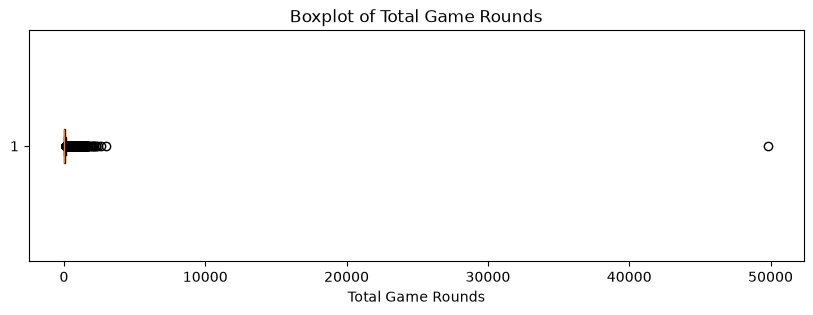

In [17]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    df["sum_gamerounds"],
    vert=False,
    patch_artist=True
)

plt.title("Boxplot of Total Game Rounds")
plt.xlabel("Total Game Rounds")

plt.show()

#### Key Insights

- The boxplot confirms the presence of numerous observations beyond the upper whisker, indicating many high-engagement players relative to the majority of the dataset.
- One observation is dramatically separated from all other values, suggesting an extremely influential outlier.
- The central 50% of player engagement occupies a relatively narrow range compared to the overall spread of the data.
- The visualization supports the findings from the histogram, summary statistics, and skewness analysis that the engagement distribution is heavily right-skewed.

#### Business Relevance

- Most players exhibit relatively low engagement, while a small number of highly active players contribute disproportionately to total gameplay.
- Extremely active users may represent legitimate "power users" rather than erroneous records, making automatic removal inappropriate.
- Further investigation is required before deciding whether these observations should be retained, transformed, or excluded from subsequent analyses.

### 2.6 Outlier Investigation

#### Objective

Identify observations classified as outliers using the Interquartile Range (IQR) method and determine whether they represent legitimate player behavior or anomalous records.

In [19]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Lower Bound : {lower_bound}")
print(f"Upper Bound : {upper_bound}")

Lower Bound : -64.0
Upper Bound : 120.0


In [20]:
outliers = df[
    (df["sum_gamerounds"] < lower_bound) |
    (df["sum_gamerounds"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 10177


In [21]:
outlier_percentage = len(outliers) / len(df) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

Outlier Percentage: 11.28%


In [22]:
outliers.sort_values(
    by="sum_gamerounds",
    ascending=False
).head(10)

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True
46344,5133952,gate_30,2251,True,True
87007,9640085,gate_30,2156,True,True
36933,4090246,gate_40,2124,True,True
88328,9791599,gate_40,2063,True,True
6536,725080,gate_40,2015,True,True


#### Key Insights

- Using the IQR method, observations above **120 game rounds** are classified as potential outliers.
- A total of **10,177 players (11.28%)** fall outside this threshold.
- Since more than one in ten players are classified as outliers, these observations likely represent a meaningful group of highly engaged players rather than isolated anomalies.
- One player completed **49,854** game rounds, far exceeding the next highest value (~2,961 rounds), making this observation worthy of further investigation.

#### Business Relevance

- Removing all IQR-defined outliers would eliminate over 11% of the player base and could bias engagement analyses.
- Highly engaged players are often strategically important because they contribute significantly to retention and long-term revenue.
- The extremely large observation should be evaluated separately to assess its influence on statistical results rather than being removed automatically.

### 2.7 Influence Analysis

#### Objective

Evaluate how much the single most extreme observation influences the overall distribution of player engagement by comparing summary statistics before and after its removal.

#### Step 1: Create a Comparison Dataset

To assess the influence of the most extreme observation, a temporary dataset is created by removing only the player with the highest number of game rounds. The original dataset remains unchanged for all subsequent analyses.

In [23]:
df_no_extreme = df[df["sum_gamerounds"] != df["sum_gamerounds"].max()].copy()

print("Original Dataset Size :", len(df))
print("Without Extreme Player:", len(df_no_extreme))

Original Dataset Size : 90189
Without Extreme Player: 90188


#### Step 2: Compare Summary Statistics

Compare key descriptive statistics before and after removing the most extreme observation to determine whether it disproportionately influences the dataset.

In [24]:
comparison = pd.DataFrame({
    "Original": df["sum_gamerounds"].describe(),
    "Without Extreme": df_no_extreme["sum_gamerounds"].describe()
})

comparison

,Original,Without Extreme
count,90189.000000,90188.000000
mean,51.872457,51.320253
std,195.050858,102.682719
min,0.000000,0.000000
25%,5.000000,5.000000
50%,16.000000,16.000000
75%,51.000000,51.000000
max,49854.000000,2961.000000


#### Step 3: Compare Key Metrics

Focus on the mean, median and standard deviation to understand whether the extreme observation substantially alters the central tendency or variability of player engagement.

In [25]:
metrics = pd.DataFrame({
    "Original": [
        df["sum_gamerounds"].mean(),
        df["sum_gamerounds"].median(),
        df["sum_gamerounds"].std()
    ],
    "Without Extreme": [
        df_no_extreme["sum_gamerounds"].mean(),
        df_no_extreme["sum_gamerounds"].median(),
        df_no_extreme["sum_gamerounds"].std()
    ]
},
index=["Mean", "Median", "Standard Deviation"])

metrics

,Original,Without Extreme
Mean,51.872457,51.320253
Median,16.000000,16.000000
Standard Deviation,195.050858,102.682719


#### Step 4: Compare Distribution Shape

Measure skewness before and after removing the extreme observation to evaluate its impact on the overall distribution.

In [26]:
print("Original Skewness :", round(df["sum_gamerounds"].skew(), 2))
print("Without Extreme   :", round(df_no_extreme["sum_gamerounds"].skew(), 2))

Original Skewness : 185.44
Without Extreme   : 5.95


#### Key Insights

- Removing the single most extreme observation reduced the mean only slightly (**51.87 → 51.32**), indicating minimal influence on average player engagement.
- The median remained unchanged at **16**, confirming that the typical player's behavior is unaffected by the extreme observation.
- The standard deviation decreased substantially (**195.05 → 102.68**), showing that the extreme player contributes heavily to the overall variability.
- Skewness dropped from **185.44** to **5.95**, demonstrating that the extreme observation largely drives the exceptionally long right tail.
- Despite removing the most extreme player, the distribution remains positively skewed, suggesting that high-engagement players are an inherent characteristic of the dataset rather than an anomaly.

#### Business Relevance

- The extreme player has little impact on the typical engagement level but substantially affects measures of variability and distribution shape.
- Retaining the original dataset preserves information about highly engaged players while avoiding unnecessary removal of potentially valuable user behavior.
- Subsequent analyses should rely on statistical methods that are robust to non-normal data rather than assuming a normal distribution.

### 2.8 Decision on Outlier Handling

#### Objective

Based on the exploratory analysis and influence assessment, determine whether the extreme observation should be retained, transformed, or excluded from subsequent analyses.

#### Decision

- The most extreme observation was retained in the primary analysis.
- Removing it had negligible impact on measures of central tendency but substantially affected distribution shape.
- Since the observation cannot be confirmed as erroneous and may represent a legitimate highly engaged player, retaining it preserves valuable behavioral information.
- Robust statistical methods will be used throughout the analysis to account for the non-normal distribution.

In [3]:
df.to_csv(
    "../data/cleaned/cookie_cats_cleaned.csv",
    index=False
)